# Phase 4 — DDPM Comparison via `diffusers`

This notebook trains the `diffusers`-based model from `dms.ddpm` side by
side with the toy `BasicUNet` from Phases 2-3, so the differences are
visible directly in code and outputs rather than just in theory.

| | Toy model (Phases 2-3) | DDPM (this phase) |
|---|---|---|
| Model | `BasicUNet` | `diffusers.UNet2DModel` |
| Noise | Uniform mix, `corrupt(x, amount)` | Gaussian, `scheduler.add_noise` |
| Objective | Predict the clean image | Predict the added noise |
| Timestep info | None -- model guesses corruption level | Passed explicitly to the model |
| Sampler | Ad hoc `1/(n_steps-i)` mixing | `DDPMScheduler.step` (real reverse process) |
| Parameters | ~309k | ~1.7M |

See `docs/COMPARISON.md` for the full written summary.

In [1]:
import torch
from matplotlib import pyplot as plt
import torchvision

from dms.data import get_dataloader
from dms.ddpm import (
    DDPMTrainConfig,
    build_ddpm_scheduler,
    build_ddpm_unet,
    sample_ddpm,
    train_ddpm,
)
from dms.models import count_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Data (same fallback strategy as Phases 2-3)

In [2]:
batch_size = 64

try:
    train_dataloader = get_dataloader(name="mnist", root="data", batch_size=batch_size, download=True)
    x, y = next(iter(train_dataloader))
    using_real_data = True
except Exception as e:
    print(f"Falling back to FakeData (real MNIST unavailable: {e})")
    fake = torchvision.datasets.FakeData(
        size=512, image_size=(1, 28, 28), num_classes=10, transform=torchvision.transforms.ToTensor()
    )
    train_dataloader = torch.utils.data.DataLoader(fake, batch_size=batch_size, shuffle=True)
    x, y = next(iter(train_dataloader))
    using_real_data = False

print("Batch shape:", x.shape, "| using real MNIST:", using_real_data)

Falling back to FakeData (real MNIST unavailable: Error downloading train-images-idx3-ubyte.gz:
Tried https://ossci-datasets.s3.amazonaws.com/mnist/, got:
HTTP Error 403: Forbidden
Tried http://yann.lecun.com/exdb/mnist/, got:
HTTP Error 403: Forbidden
)
Batch shape: torch.Size([64, 1, 28, 28]) | using real MNIST: False


## Build the DDPM model and scheduler

`build_ddpm_unet()` defaults to the same configuration as the original
notebook: 3 down/up blocks with attention in the deeper two, ~1.7M
parameters -- about 5.5x `BasicUNet`'s ~309k.

In [3]:
ddpm_net = build_ddpm_unet(sample_size=28, in_channels=1, out_channels=1)
scheduler = build_ddpm_scheduler(num_train_timesteps=1000)

print("UNet2DModel parameter count:", count_parameters(ddpm_net))
print("Scheduler:", scheduler.config.num_train_timesteps, "training timesteps,",
      scheduler.config.beta_schedule, "beta schedule")

UNet2DModel parameter count: 1707009
Scheduler: 1000 training timesteps, linear beta schedule


## Train

Same number of epochs as the Phase 3 `BasicUNet` run, for a fair
side-by-side loss comparison. Note the loss here is against the
*predicted noise*, not the image -- so the absolute loss values aren't
directly comparable to Phase 3's, only the trend.

In [4]:
config = DDPMTrainConfig(epochs=3, lr=4e-4, device=str(device), log_every=0)
result = train_ddpm(ddpm_net, scheduler, train_dataloader, config)
print("Final epoch mean losses:", [round(l, 4) for l in result.epoch_mean_losses])

epoch 0: mean loss=0.4543


epoch 1: mean loss=0.1794


epoch 2: mean loss=0.1653
Final epoch mean losses: [0.4543, 0.1794, 0.1653]


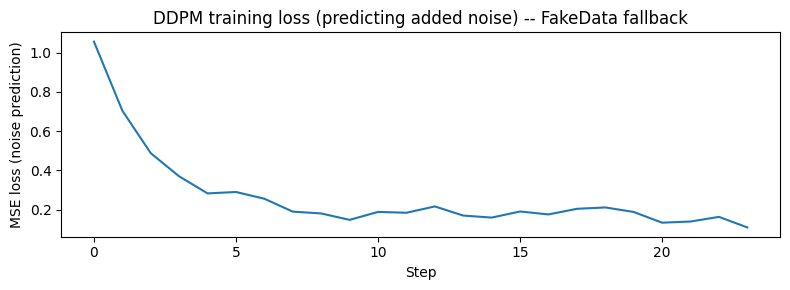

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(result.losses)
plt.title("DDPM training loss (predicting added noise)" + ("" if using_real_data else " -- FakeData fallback"))
plt.xlabel("Step")
plt.ylabel("MSE loss (noise prediction)")
plt.tight_layout()
plt.savefig("../docs/assets/ddpm_training_loss.png", dpi=100)
plt.show()

## Sample using the real reverse-diffusion process

`sample_ddpm` starts from Gaussian noise and repeatedly calls
`scheduler.step`, which applies the actual reverse-process update implied
by the beta schedule -- a principled replacement for Phase 3's ad hoc
mixing rule.

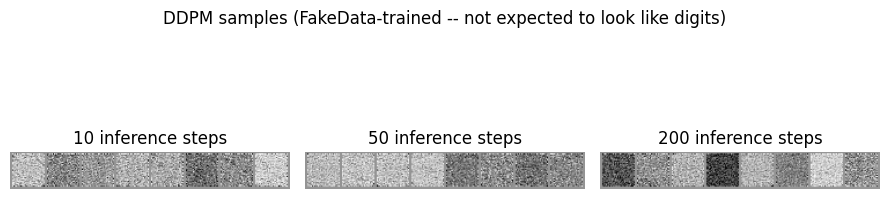

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for ax, n_steps in zip(axs, [10, 50, 200]):
    samples = sample_ddpm(ddpm_net, scheduler, shape=(8, 1, 28, 28), device=str(device), num_inference_steps=n_steps)
    grid = torchvision.utils.make_grid(samples.clamp(-1, 1))
    ax.imshow(grid.permute(1, 2, 0)[..., 0], cmap="Greys")
    ax.set_title(f"{n_steps} inference steps")
    ax.axis("off")
plt.suptitle("DDPM samples" + ("" if using_real_data else " (FakeData-trained -- not expected to look like digits)"))
plt.tight_layout()
plt.savefig("../docs/assets/ddpm_samples_by_step_count.png", dpi=100)
plt.show()

## Visualize the reverse-diffusion trajectory

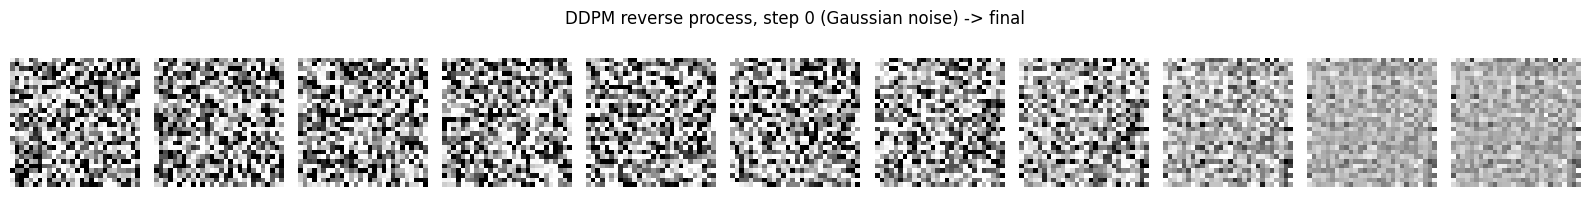

In [7]:
samples, step_history = sample_ddpm(
    ddpm_net, scheduler, shape=(1, 1, 28, 28), device=str(device),
    num_inference_steps=10, return_intermediates=True,
)

fig, axs = plt.subplots(1, len(step_history), figsize=(16, 2))
for ax, step_x in zip(axs, step_history):
    ax.imshow(step_x[0, 0].clamp(-1, 1), cmap="Greys")
    ax.axis("off")
plt.suptitle("DDPM reverse process, step 0 (Gaussian noise) -> final")
plt.tight_layout()
plt.savefig("../docs/assets/ddpm_trajectory.png", dpi=100)
plt.show()

## Save a checkpoint, and wrap up

This is the final phase of the project. See `docs/COMPARISON.md` for the
full written summary of every difference between the toy model
(Phases 2-3) and this DDPM (Phase 4), and the top-level `README.md` for
the finished project overview.

In [8]:
import os
os.makedirs("../checkpoints", exist_ok=True)
torch.save(ddpm_net.state_dict(), "../checkpoints/ddpm_unet_phase4.pt")
print("Saved to ../checkpoints/ddpm_unet_phase4.pt")

Saved to ../checkpoints/ddpm_unet_phase4.pt
